In [1]:
# ============================================================
# PART 1: IMPORT REQUIRED LIBRARIES
# Cardiovascular Disease Risk Prediction & Explainable AI
# ============================================================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder
)

from sklearn.impute import SimpleImputer

# Machine Learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# XGBoost
from xgboost import XGBClassifier

# LightGBM
from lightgbm import LGBMClassifier

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Model calibration
from sklearn.calibration import (
    calibration_curve,
    CalibratedClassifierCV
)

# SHAP Explainable AI
import shap

# Statistical utilities
from scipy import stats

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("All required libraries imported successfully.")

All required libraries imported successfully.


In [2]:
# ============================================================
# PART 2: EXTRACT AND LOAD DATASET
# ============================================================

import os
import zipfile
import pandas as pd

# Path to uploaded ZIP file
zip_path = "/content/dataset.zip"

# Directory where the dataset will be extracted
extract_path = "/content/cvd_dataset"

# Create extraction directory
os.makedirs(extract_path, exist_ok=True)

# Extract ZIP file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")
print("\nExtracted files:")

for root, dirs, files in os.walk(extract_path):
    for file in files:
        print(os.path.join(root, file))

Dataset extracted successfully.

Extracted files:
/content/cvd_dataset/cardio_data_processed.csv


In [3]:
# ============================================================
# PART 2: LOAD CARDIOVASCULAR DISEASE DATASET
# ============================================================

dataset_path = "/content/cvd_dataset/cardio_data_processed.csv"

df = pd.read_csv(dataset_path)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset shape: (68205, 17)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,bp_category,bp_category_encoded
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50,21.967120,Hypertension Stage 1,Hypertension Stage 1
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55,34.927679,Hypertension Stage 2,Hypertension Stage 2
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51,23.507805,Hypertension Stage 1,Hypertension Stage 1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48,28.710479,Hypertension Stage 2,Hypertension Stage 2
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47,23.011177,Normal,Normal


In [4]:
# ============================================================
# DATASET INFORMATION
# ============================================================

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Number of rows: 68205
Number of columns: 17

Column names:
['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'age_years', 'bmi', 'bp_category', 'bp_category_encoded']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68205 entries, 0 to 68204
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   68205 non-null  int64  
 1   age                  68205 non-null  int64  
 2   gender               68205 non-null  int64  
 3   height               68205 non-null  int64  
 4   weight               68205 non-null  float64
 5   ap_hi                68205 non-null  int64  
 6   ap_lo                68205 non-null  int64  
 7   cholesterol          68205 non-null  int64  
 8   gluc                 68205 non-null  int64  
 9   smoke                68205 non-null  int64  
 10  alco                 6820

In [5]:
# ============================================================
# CHECK MISSING VALUES
# ============================================================

missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    "Column": missing_values.index,
    "Missing Values": missing_values.values,
    "Missing Percentage": (missing_values.values / len(df)) * 100
})

display(missing_table)

,Column,Missing Values,Missing Percentage
0,id,0,0.0
1,age,0,0.0
2,gender,0,0.0
3,height,0,0.0
4,weight,0,0.0
5,ap_hi,0,0.0
6,ap_lo,0,0.0
7,cholesterol,0,0.0
8,gluc,0,0.0
9,smoke,0,0.0


In [6]:
# ============================================================
# CHECK DATA TYPES
# ============================================================

dtype_table = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Unique Values": [df[col].nunique() for col in df.columns]
})

display(dtype_table)

,Column,Data Type,Unique Values
0,id,int64,68205
1,age,int64,8061
2,gender,int64,2
3,height,int64,106
4,weight,float64,278
5,ap_hi,int64,86
6,ap_lo,int64,58
7,cholesterol,int64,3
8,gluc,int64,3
9,smoke,int64,2


In [7]:
# ============================================================
# CHECK TARGET VARIABLE
# ============================================================

print("Available columns:")
print(df.columns.tolist())

if "cardio" in df.columns:
    print("\nTarget variable: cardio")
    print("\nTarget distribution:")
    print(df["cardio"].value_counts())

    print("\nTarget distribution (%):")
    print((df["cardio"].value_counts(normalize=True) * 100).round(2))
else:
    print("\n'cardio' column was not found.")
    print("Please check the column names above.")

Available columns:
['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'age_years', 'bmi', 'bp_category', 'bp_category_encoded']

Target variable: cardio

Target distribution:
cardio
0    34533
1    33672
Name: count, dtype: int64

Target distribution (%):
cardio
0    50.63
1    49.37
Name: proportion, dtype: float64


In [8]:
# ============================================================
# STATISTICAL SUMMARY
# ============================================================

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
id,68205.0,49972.410498,28852.138290,0.000000,24991.000000,50008.000000,74878.000000,99999.000000
age,68205.0,19462.667737,2468.381854,10798.000000,17656.000000,19700.000000,21323.000000,23713.000000
gender,68205.0,1.348625,0.476539,1.000000,1.000000,1.000000,2.000000,2.000000
height,68205.0,164.372861,8.176756,55.000000,159.000000,165.000000,170.000000,250.000000
weight,68205.0,74.100688,14.288862,11.000000,65.000000,72.000000,82.000000,200.000000
ap_hi,68205.0,126.434924,15.961685,90.000000,120.000000,120.000000,140.000000,180.000000
ap_lo,68205.0,81.263925,9.143985,60.000000,80.000000,80.000000,90.000000,120.000000
cholesterol,68205.0,1.363243,0.678080,1.000000,1.000000,1.000000,1.000000,3.000000
gluc,68205.0,1.225174,0.571288,1.000000,1.000000,1.000000,1.000000,3.000000
smoke,68205.0,0.087662,0.282805,0.000000,0.000000,0.000000,0.000000,1.000000


In [9]:
# ============================================================
# PART 3.1: CHECK DUPLICATE RECORDS
# ============================================================

duplicate_rows = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_rows)

if duplicate_rows == 0:
    print("No duplicate rows found.")
else:
    print("Duplicate rows detected.")

Number of duplicate rows: 0
No duplicate rows found.


In [10]:
# ============================================================
# CHECK DUPLICATE IDs
# ============================================================

duplicate_ids = df["id"].duplicated().sum()

print("Number of duplicate IDs:", duplicate_ids)

if duplicate_ids == 0:
    print("All patient IDs are unique.")
else:
    print("Duplicate patient IDs detected.")

Number of duplicate IDs: 0
All patient IDs are unique.


In [11]:
# ============================================================
# CATEGORICAL VARIABLE DISTRIBUTIONS
# ============================================================

categorical_columns = [
    "gender",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active",
    "cardio"
]

for column in categorical_columns:
    print(f"\n{'=' * 50}")
    print(f"{column.upper()}")
    print("=" * 50)
    print(df[column].value_counts())
    print("\nPercentage:")
    print((df[column].value_counts(normalize=True) * 100).round(2))


GENDER
gender
1    44427
2    23778
Name: count, dtype: int64

Percentage:
gender
1    65.14
2    34.86
Name: proportion, dtype: float64

CHOLESTEROL
cholesterol
1    51222
2     9191
3     7792
Name: count, dtype: int64

Percentage:
cholesterol
1    75.10
2    13.48
3    11.42
Name: proportion, dtype: float64

GLUC
gluc
1    58027
3     5180
2     4998
Name: count, dtype: int64

Percentage:
gluc
1    85.08
3     7.59
2     7.33
Name: proportion, dtype: float64

SMOKE
smoke
0    62226
1     5979
Name: count, dtype: int64

Percentage:
smoke
0    91.23
1     8.77
Name: proportion, dtype: float64

ALCO
alco
0    64581
1     3624
Name: count, dtype: int64

Percentage:
alco
0    94.69
1     5.31
Name: proportion, dtype: float64

ACTIVE
active
1    54806
0    13399
Name: count, dtype: int64

Percentage:
active
1    80.35
0    19.65
Name: proportion, dtype: float64

CARDIO
cardio
0    34533
1    33672
Name: count, dtype: int64

Percentage:
cardio
0    50.63
1    49.37
Name: proportion, dtype

In [12]:
# ============================================================
# BLOOD PRESSURE CATEGORY DISTRIBUTION
# ============================================================

print("Blood Pressure Category Distribution:")
print(df["bp_category"].value_counts())

print("\nPercentage Distribution:")
print(
    (df["bp_category"].value_counts(normalize=True) * 100)
    .round(2)
)

Blood Pressure Category Distribution:
bp_category
Hypertension Stage 1    39750
Hypertension Stage 2    15937
Normal                   9417
Elevated                 3101
Name: count, dtype: int64

Percentage Distribution:
bp_category
Hypertension Stage 1    58.28
Hypertension Stage 2    23.37
Normal                  13.81
Elevated                 4.55
Name: proportion, dtype: float64


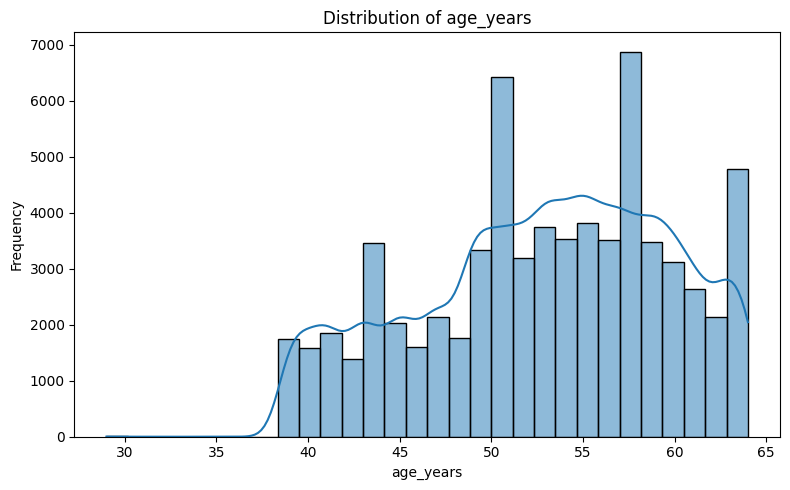

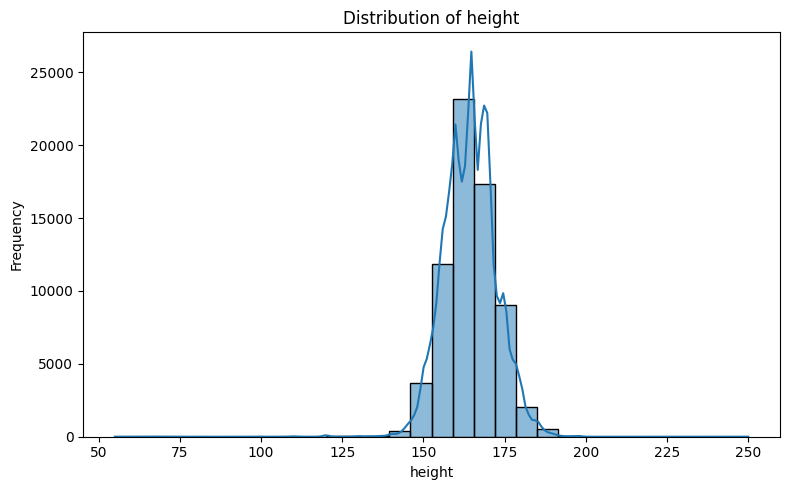

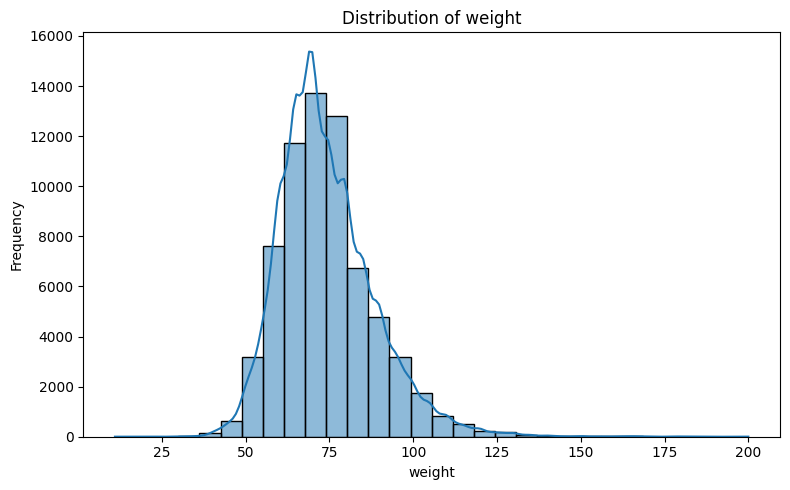

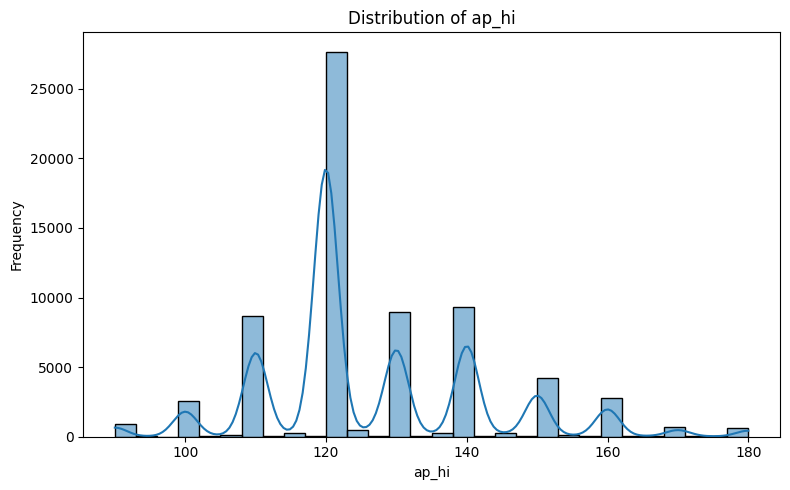

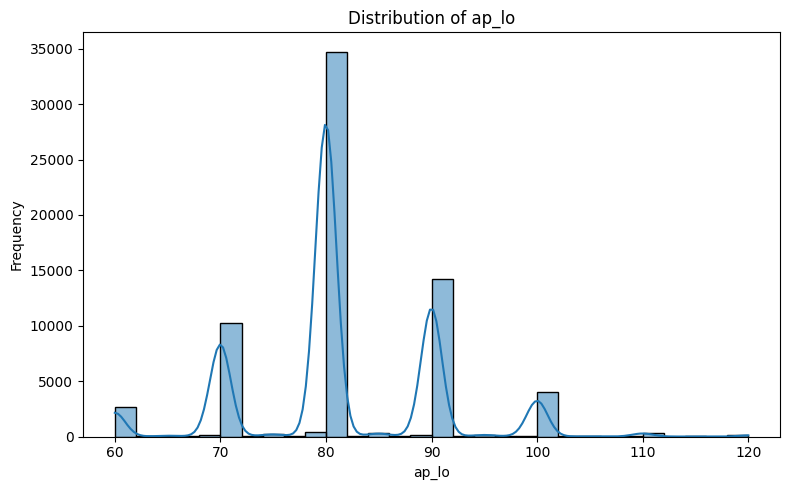

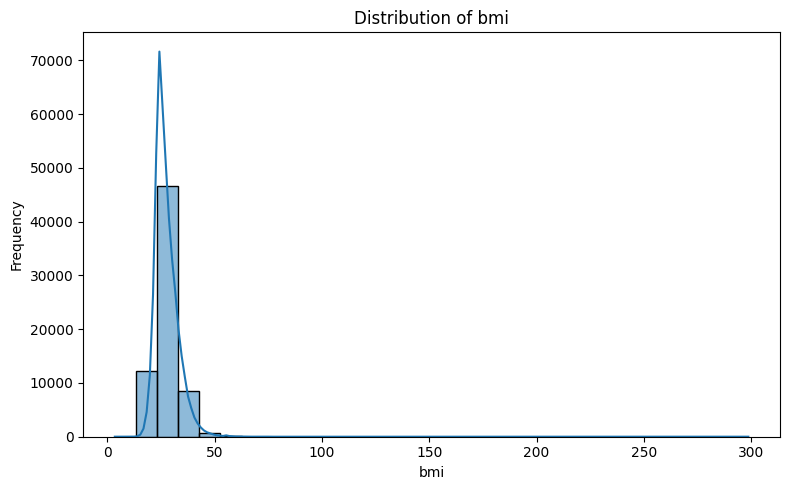

In [13]:
# ============================================================
# NUMERICAL VARIABLE DISTRIBUTIONS
# ============================================================

numerical_columns = [
    "age_years",
    "height",
    "weight",
    "ap_hi",
    "ap_lo",
    "bmi"
]

for column in numerical_columns:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=column,
        kde=True,
        bins=30
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

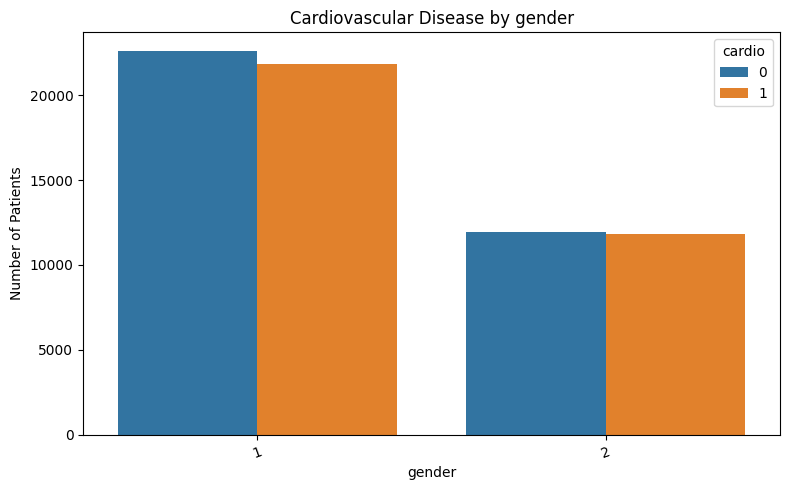

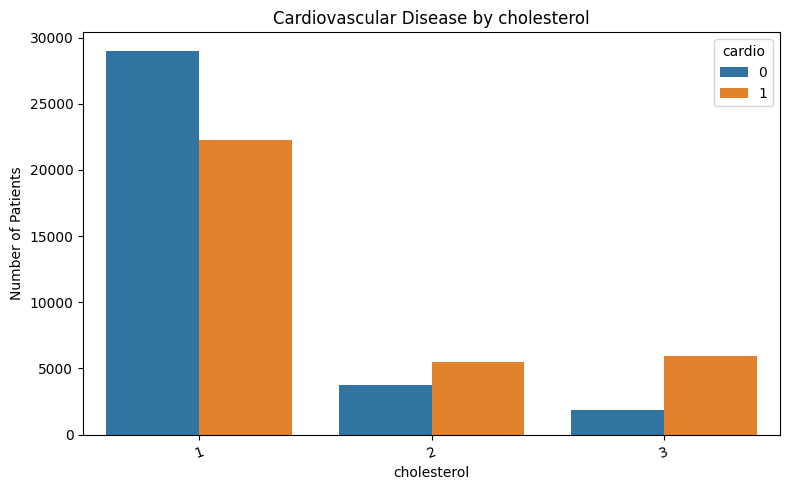

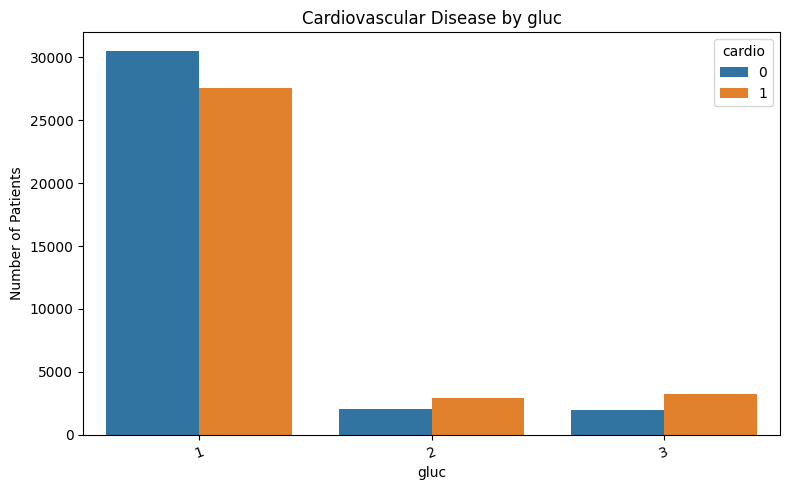

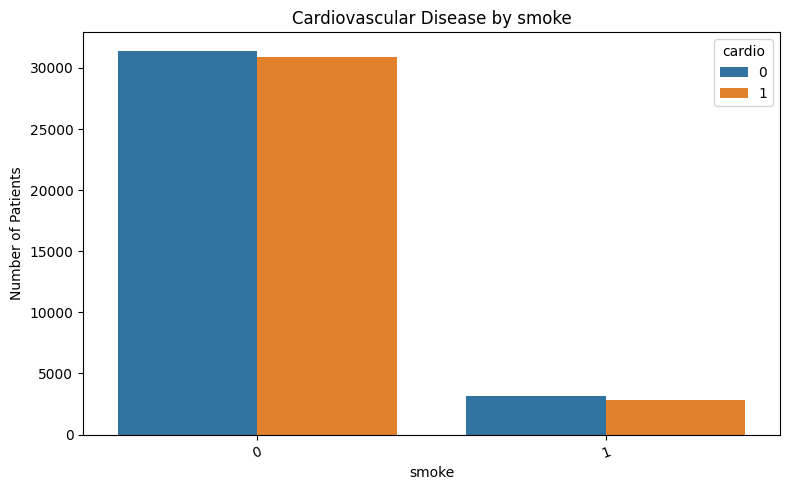

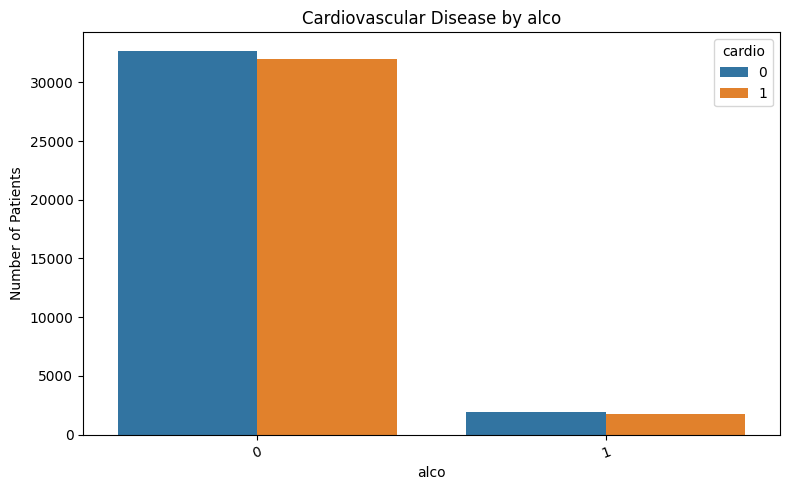

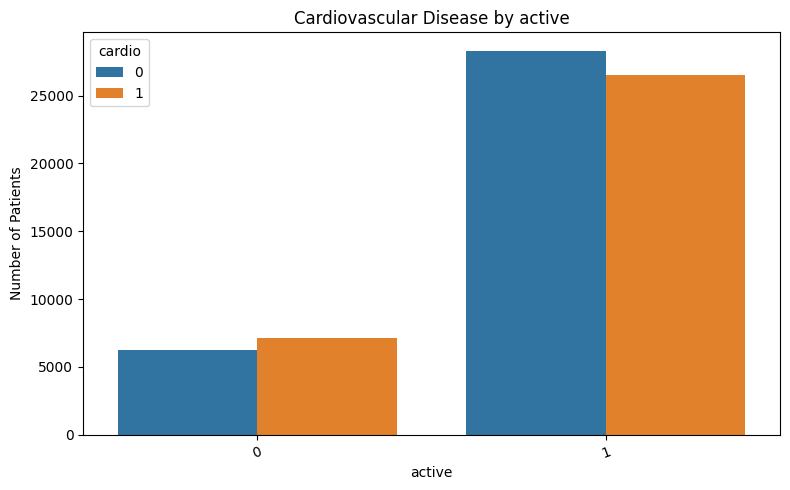

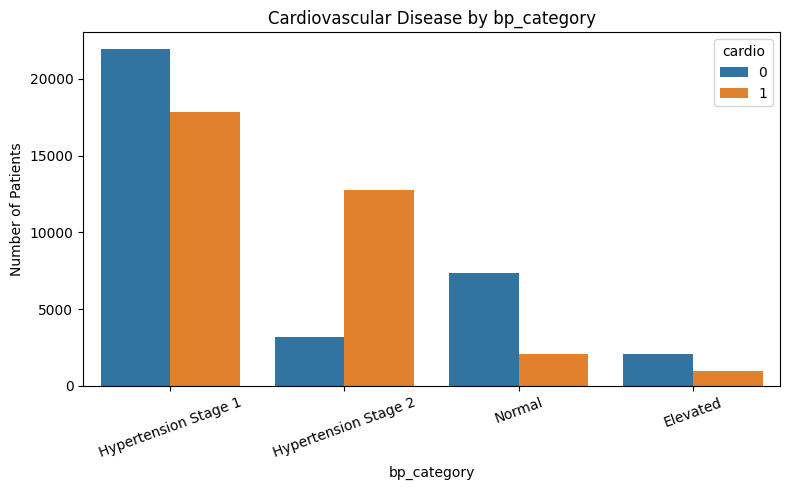

In [14]:
# ============================================================
# CVD DISTRIBUTION BY IMPORTANT RISK FACTORS
# ============================================================

risk_factors = [
    "gender",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active",
    "bp_category"
]

for column in risk_factors:

    plt.figure(figsize=(8, 5))

    sns.countplot(
        data=df,
        x=column,
        hue="cardio"
    )

    plt.title(f"Cardiovascular Disease by {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Patients")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

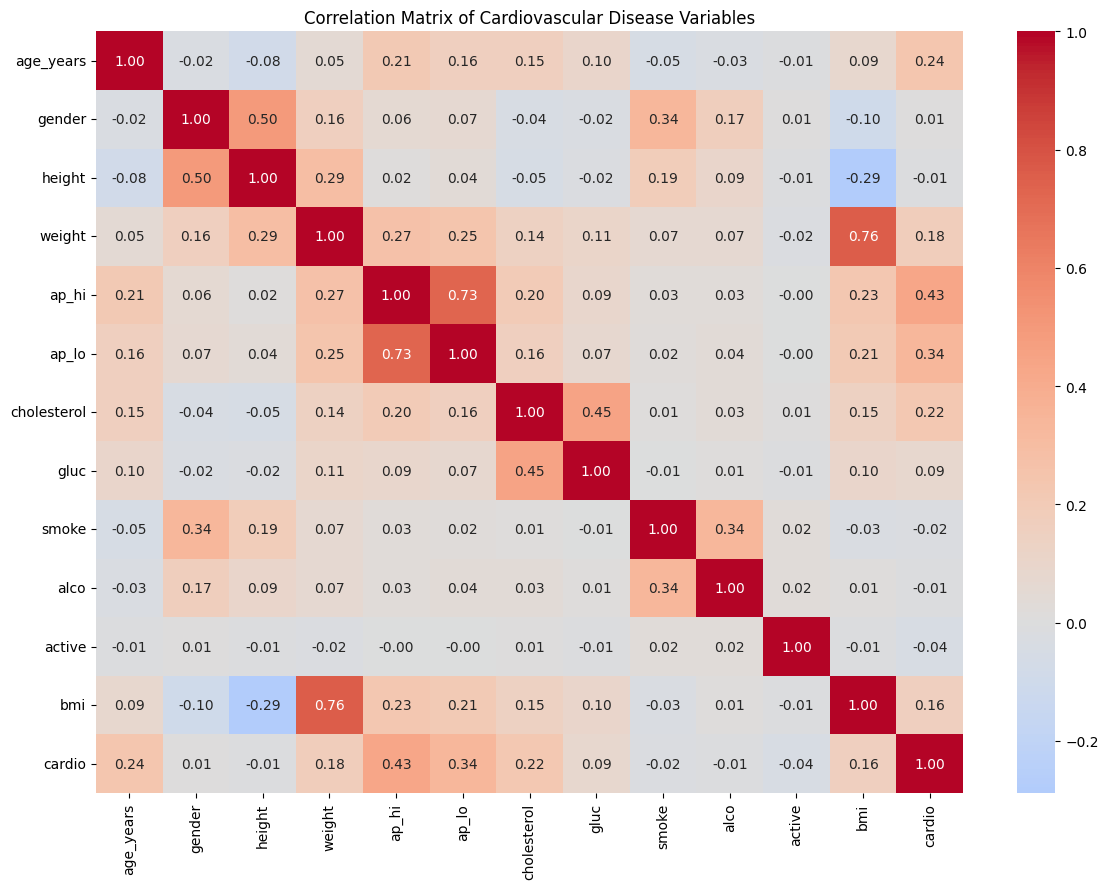

In [15]:
# ============================================================
# CORRELATION ANALYSIS
# ============================================================

correlation_columns = [
    "age_years",
    "gender",
    "height",
    "weight",
    "ap_hi",
    "ap_lo",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active",
    "bmi",
    "cardio"
]

correlation_matrix = df[correlation_columns].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Cardiovascular Disease Variables")
plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# PART 4.1: CREATE WORKING COPY
# ============================================================

df_clean = df.copy()

print("Working dataset created.")
print("Initial shape:", df_clean.shape)

Working dataset created.
Initial shape: (68205, 17)


In [17]:
# ============================================================
# PART 4.2: REMOVE DUPLICATES
# ============================================================

before_duplicates = len(df_clean)

df_clean = df_clean.drop_duplicates()

after_duplicates = len(df_clean)

print("Rows before duplicate removal:", before_duplicates)
print("Rows after duplicate removal:", after_duplicates)
print("Duplicates removed:", before_duplicates - after_duplicates)

Rows before duplicate removal: 68205
Rows after duplicate removal: 68205
Duplicates removed: 0


In [18]:
# ============================================================
# PART 4.3: REMOVE IDENTIFIER
# ============================================================

if "id" in df_clean.columns:
    df_clean = df_clean.drop(columns=["id"])

print("ID column removed.")
print("Current shape:", df_clean.shape)

ID column removed.
Current shape: (68205, 16)


In [19]:
# ============================================================
# PART 4.4: CHECK POTENTIALLY UNREALISTIC VALUES
# ============================================================

print("Height range:")
print(df_clean["height"].min(), "to", df_clean["height"].max())

print("\nWeight range:")
print(df_clean["weight"].min(), "to", df_clean["weight"].max())

print("\nSystolic BP range:")
print(df_clean["ap_hi"].min(), "to", df_clean["ap_hi"].max())

print("\nDiastolic BP range:")
print(df_clean["ap_lo"].min(), "to", df_clean["ap_lo"].max())

print("\nBMI range:")
print(df_clean["bmi"].min(), "to", df_clean["bmi"].max())

Height range:
55 to 250

Weight range:
11.0 to 200.0

Systolic BP range:
90 to 180

Diastolic BP range:
60 to 120

BMI range:
3.471783865673526 to 298.6666666666667


In [20]:
# ============================================================
# PART 4.5: HANDLE IMPLAUSIBLE CLINICAL VALUES
# ============================================================

before_filter = len(df_clean)

df_clean = df_clean[
    (df_clean["height"] >= 120) &
    (df_clean["height"] <= 220) &
    (df_clean["weight"] >= 30) &
    (df_clean["weight"] <= 200) &
    (df_clean["ap_hi"] >= 70) &
    (df_clean["ap_hi"] <= 250) &
    (df_clean["ap_lo"] >= 40) &
    (df_clean["ap_lo"] <= 150) &
    (df_clean["ap_hi"] >= df_clean["ap_lo"])
].copy()

after_filter = len(df_clean)

print("Rows before clinical filtering:", before_filter)
print("Rows after clinical filtering:", after_filter)
print("Rows removed:", before_filter - after_filter)

Rows before clinical filtering: 68205
Rows after clinical filtering: 68147
Rows removed: 58


In [21]:
# ============================================================
# PART 4.6: RECALCULATE BMI
# ============================================================

df_clean["bmi_calculated"] = (
    df_clean["weight"] /
    ((df_clean["height"] / 100) ** 2)
)

print("Calculated BMI successfully.")

display(
    df_clean[
        ["height", "weight", "bmi", "bmi_calculated"]
    ].head(10)
)

Calculated BMI successfully.


,height,weight,bmi,bmi_calculated
0,168,62.0,21.967120,21.967120
1,156,85.0,34.927679,34.927679
2,165,64.0,23.507805,23.507805
3,169,82.0,28.710479,28.710479
4,156,56.0,23.011177,23.011177
5,151,67.0,29.384676,29.384676
6,157,93.0,37.729725,37.729725
7,178,95.0,29.983588,29.983588
8,158,71.0,28.440955,28.440955
9,164,68.0,25.282570,25.282570


In [22]:
# ============================================================
# PART 4.7: CREATE BMI CATEGORIES
# ============================================================

def classify_bmi(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"

df_clean["bmi_category"] = df_clean["bmi_calculated"].apply(
    classify_bmi
)

print("BMI categories:")
print(df_clean["bmi_category"].value_counts())

BMI categories:
bmi_category
Normal         25294
Overweight     24469
Obese          17760
Underweight      624
Name: count, dtype: int64


In [23]:
# ============================================================
# PART 4.8: CREATE PULSE PRESSURE
# ============================================================

df_clean["pulse_pressure"] = (
    df_clean["ap_hi"] - df_clean["ap_lo"]
)

print("Pulse pressure created.")

display(
    df_clean[
        ["ap_hi", "ap_lo", "pulse_pressure"]
    ].head(10)
)

Pulse pressure created.


,ap_hi,ap_lo,pulse_pressure
0,110,80,30
1,140,90,50
2,130,70,60
3,150,100,50
4,100,60,40
5,120,80,40
6,130,80,50
7,130,90,40
8,110,70,40
9,110,60,50


In [24]:
# ============================================================
# PART 4.9: CREATE AGE GROUPS
# ============================================================

age_bins = [0, 30, 45, 60, 100]

age_labels = [
    "18-30",
    "31-45",
    "46-60",
    "60+"
]

df_clean["age_group"] = pd.cut(
    df_clean["age_years"],
    bins=age_bins,
    labels=age_labels,
    right=True
)

print("Age group distribution:")
print(df_clean["age_group"].value_counts().sort_index())

Age group distribution:
age_group
18-30        4
31-45    12069
46-60    46525
60+       9549
Name: count, dtype: int64


In [25]:
# ============================================================
# PART 4.10: CREATE LIFESTYLE RISK SCORE
# ============================================================

df_clean["lifestyle_risk_score"] = (
    df_clean["smoke"] +
    df_clean["alco"] +
    (1 - df_clean["active"])
)

print("Lifestyle risk score distribution:")
print(
    df_clean["lifestyle_risk_score"]
    .value_counts()
    .sort_index()
)

Lifestyle risk score distribution:
lifestyle_risk_score
0    48217
1    17151
2     2506
3      273
Name: count, dtype: int64


In [26]:
# ============================================================
# PART 4.11: REVIEW ENGINEERED FEATURES
# ============================================================

engineered_features = [
    "age_years",
    "bmi_calculated",
    "bmi_category",
    "pulse_pressure",
    "age_group",
    "lifestyle_risk_score"
]

display(df_clean[engineered_features].head(10))

,age_years,bmi_calculated,bmi_category,pulse_pressure,age_group,lifestyle_risk_score
0,50,21.967120,Normal,30,46-60,0
1,55,34.927679,Obese,50,46-60,0
2,51,23.507805,Normal,60,46-60,1
3,48,28.710479,Overweight,50,46-60,0
4,47,23.011177,Normal,40,46-60,1
5,60,29.384676,Overweight,40,46-60,1
6,60,37.729725,Obese,50,46-60,0
7,61,29.983588,Overweight,40,60+,0
8,48,28.440955,Overweight,40,46-60,0
9,54,25.282570,Overweight,50,46-60,1


In [27]:
# ============================================================
# PART 4.12: FINAL CLEANING CHECK
# ============================================================

print("Final dataset shape:", df_clean.shape)

print("\nMissing values:")
print(df_clean.isnull().sum())

print("\nTarget distribution:")
print(df_clean["cardio"].value_counts())

print("\nTarget percentages:")
print(
    (df_clean["cardio"].value_counts(normalize=True) * 100)
    .round(2)
)

Final dataset shape: (68147, 21)

Missing values:
age                     0
gender                  0
height                  0
weight                  0
ap_hi                   0
ap_lo                   0
cholesterol             0
gluc                    0
smoke                   0
alco                    0
active                  0
cardio                  0
age_years               0
bmi                     0
bp_category             0
bp_category_encoded     0
bmi_calculated          0
bmi_category            0
pulse_pressure          0
age_group               0
lifestyle_risk_score    0
dtype: int64

Target distribution:
cardio
0    34504
1    33643
Name: count, dtype: int64

Target percentages:
cardio
0    50.63
1    49.37
Name: proportion, dtype: float64


In [28]:
# ============================================================
# PART 5.1: DEFINE BASELINE FEATURES
# ============================================================

baseline_features = [
    "age_years",
    "gender",
    "height",
    "weight",
    "ap_hi",
    "ap_lo",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active"
]

X_baseline = df_clean[baseline_features].copy()
y = df_clean["cardio"].copy()

print("Baseline feature set created.")
print("Number of baseline features:", X_baseline.shape[1])
print("\nBaseline features:")
print(baseline_features)

print("\nBaseline feature shape:", X_baseline.shape)
print("Target shape:", y.shape)

Baseline feature set created.
Number of baseline features: 11

Baseline features:
['age_years', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']

Baseline feature shape: (68147, 11)
Target shape: (68147,)


In [29]:
# ============================================================
# PART 5.2: DEFINE ENGINEERED FEATURES
# ============================================================

engineered_features = [
    "age_years",
    "gender",
    "height",
    "weight",
    "ap_hi",
    "ap_lo",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active",
    "bmi_calculated",
    "pulse_pressure",
    "lifestyle_risk_score"
]

X_engineered = df_clean[engineered_features].copy()

print("Engineered feature set created.")
print("Number of engineered features:", X_engineered.shape[1])

print("\nEngineered features:")
print(engineered_features)

print("\nEngineered feature shape:", X_engineered.shape)

Engineered feature set created.
Number of engineered features: 14

Engineered features:
['age_years', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi_calculated', 'pulse_pressure', 'lifestyle_risk_score']

Engineered feature shape: (68147, 14)


In [30]:
# ============================================================
# PART 5.4: CHECK FEATURE DATA TYPES
# ============================================================

print("Baseline data types:")
print(X_baseline.dtypes)

print("\nEngineered data types:")
print(X_engineered.dtypes)

Baseline data types:
age_years        int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
dtype: object

Engineered data types:
age_years                 int64
gender                    int64
height                    int64
weight                  float64
ap_hi                     int64
ap_lo                     int64
cholesterol               int64
gluc                      int64
smoke                     int64
alco                      int64
active                    int64
bmi_calculated          float64
pulse_pressure            int64
lifestyle_risk_score      int64
dtype: object


In [31]:
# ============================================================
# PART 5.5: TRAIN-TEST SPLIT
# ============================================================

X_base_train, X_base_test, y_train, y_test = train_test_split(
    X_baseline,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Baseline dataset split:")
print("Training samples:", X_base_train.shape[0])
print("Testing samples:", X_base_test.shape[0])

Baseline dataset split:
Training samples: 54517
Testing samples: 13630


In [32]:
# ============================================================
# PART 5.6: ENGINEERED FEATURE TRAIN-TEST SPLIT
# ============================================================

X_eng_train, X_eng_test, _, _ = train_test_split(
    X_engineered,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Engineered dataset split:")
print("Training samples:", X_eng_train.shape[0])
print("Testing samples:", X_eng_test.shape[0])

Engineered dataset split:
Training samples: 54517
Testing samples: 13630


In [33]:
# ============================================================
# PART 5.7: VERIFY CLASS DISTRIBUTION
# ============================================================

print("Training target distribution:")
print(y_train.value_counts())

print("\nTraining target percentage:")
print(
    (y_train.value_counts(normalize=True) * 100).round(2)
)

print("\nTesting target distribution:")
print(y_test.value_counts())

print("\nTesting target percentage:")
print(
    (y_test.value_counts(normalize=True) * 100).round(2)
)

Training target distribution:
cardio
0    27603
1    26914
Name: count, dtype: int64

Training target percentage:
cardio
0    50.63
1    49.37
Name: proportion, dtype: float64

Testing target distribution:
cardio
0    6901
1    6729
Name: count, dtype: int64

Testing target percentage:
cardio
0    50.63
1    49.37
Name: proportion, dtype: float64


In [34]:
# ============================================================
# PART 5.8: FEATURE SCALING FOR LOGISTIC REGRESSION
# ============================================================

scaler_baseline = StandardScaler()

X_base_train_scaled = scaler_baseline.fit_transform(X_base_train)
X_base_test_scaled = scaler_baseline.transform(X_base_test)

scaler_engineered = StandardScaler()

X_eng_train_scaled = scaler_engineered.fit_transform(X_eng_train)
X_eng_test_scaled = scaler_engineered.transform(X_eng_test)

print("Feature scaling completed.")
print("Baseline scaled training shape:", X_base_train_scaled.shape)
print("Engineered scaled training shape:", X_eng_train_scaled.shape)

Feature scaling completed.
Baseline scaled training shape: (54517, 11)
Engineered scaled training shape: (54517, 14)


In [35]:
# ============================================================
# PART 5.9: FINAL DATA PREPARATION CHECK
# ============================================================

print("=" * 60)
print("FINAL DATA PREPARATION SUMMARY")
print("=" * 60)

print("\nTotal records:", len(df_clean))

print("\nBaseline features:", X_baseline.shape[1])
print("Engineered features:", X_engineered.shape[1])

print("\nTraining records:", len(X_base_train))
print("Testing records:", len(X_base_test))

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

print("\nData preparation completed successfully.")

FINAL DATA PREPARATION SUMMARY

Total records: 68147

Baseline features: 11
Engineered features: 14

Training records: 54517
Testing records: 13630

Training target distribution:
cardio
0    27603
1    26914
Name: count, dtype: int64

Testing target distribution:
cardio
0    6901
1    6729
Name: count, dtype: int64

Data preparation completed successfully.


In [36]:
# ============================================================
# INSTALL DEEP LEARNING LIBRARY
# ============================================================

!pip install -q tensorflow

In [37]:
# ============================================================
# IMPORT DEEP LEARNING LIBRARIES
# ============================================================

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [38]:
# ============================================================
# MODEL 1: LOGISTIC REGRESSION
# ============================================================

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_eng_train_scaled,
    y_train
)

logistic_predictions = logistic_model.predict(
    X_eng_test_scaled
)

logistic_probabilities = logistic_model.predict_proba(
    X_eng_test_scaled
)[:, 1]

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [39]:
# ============================================================
# MODEL 2: RANDOM FOREST
# ============================================================

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_eng_train,
    y_train
)

rf_predictions = random_forest_model.predict(
    X_eng_test
)

rf_probabilities = random_forest_model.predict_proba(
    X_eng_test
)[:, 1]

print("Random Forest training completed.")

Random Forest training completed.


In [40]:
# ============================================================
# MODEL 3: XGBOOST
# ============================================================

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_model.fit(
    X_eng_train,
    y_train
)

xgb_predictions = xgb_model.predict(
    X_eng_test
)

xgb_probabilities = xgb_model.predict_proba(
    X_eng_test
)[:, 1]

print("XGBoost training completed.")

XGBoost training completed.


In [41]:
# ============================================================
# MODEL 4: ARTIFICIAL NEURAL NETWORK (ANN)
# ============================================================

ann_model = Sequential([
    Dense(64, activation="relu", input_shape=(X_eng_train_scaled.shape[1],)),
    Dropout(0.30),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

ann_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

ann_history = ann_model.fit(
    X_eng_train_scaled,
    y_train,
    validation_split=0.20,
    epochs=100,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

ann_probabilities = ann_model.predict(
    X_eng_test_scaled,
    verbose=0
).ravel()

ann_predictions = (
    ann_probabilities >= 0.5
).astype(int)

print("ANN training completed.")

Epoch 1/100
682/682 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7155 - loss: 0.5688 - val_accuracy: 0.7264 - val_loss: 0.5528
Epoch 2/100
682/682 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7287 - loss: 0.5534 - val_accuracy: 0.7266 - val_loss: 0.5530
Epoch 3/100
682/682 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7298 - loss: 0.5491 - val_accuracy: 0.7251 - val_loss: 0.5502
Epoch 4/100
682/682 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7295 - loss: 0.5484 - val_accuracy: 0.7281 - val_loss: 0.5510
Epoch 5/100
682/682 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7313 - loss: 0.5479 - val_accuracy: 0.7292 - val_loss: 0.5500
Epoch 6/100
682/682 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7329 - loss: 0.5476 - val_accuracy: 0.7278 - val_loss: 0.5493
Epoch 7/100
682/682 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7330 - loss: 0.5460 - val_accuracy: 0.7278 - val_loss: 0.5507
Epoch 8/100
682/682 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7343 - loss: 0.5447 - val_accu

In [42]:
# ============================================================
# MODEL 5: DEEP NEURAL NETWORK (DNN)
# ============================================================

dnn_model = Sequential([
    Dense(128, activation="relu", input_shape=(X_eng_train_scaled.shape[1],)),
    Dropout(0.30),

    Dense(64, activation="relu"),
    Dropout(0.30),

    Dense(32, activation="relu"),
    Dropout(0.20),

    Dense(16, activation="relu"),

    Dense(1, activation="sigmoid")
])

dnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

dnn_history = dnn_model.fit(
    X_eng_train_scaled,
    y_train,
    validation_split=0.20,
    epochs=100,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

dnn_probabilities = dnn_model.predict(
    X_eng_test_scaled,
    verbose=0
).ravel()

dnn_predictions = (
    dnn_probabilities >= 0.5
).astype(int)

print("DNN training completed.")

Epoch 1/100
682/682 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.7165 - loss: 0.5710 - val_accuracy: 0.7262 - val_loss: 0.5529
Epoch 2/100
682/682 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7287 - loss: 0.5575 - val_accuracy: 0.7267 - val_loss: 0.5542
Epoch 3/100
682/682 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7301 - loss: 0.5536 - val_accuracy: 0.7268 - val_loss: 0.5527
Epoch 4/100
682/682 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7314 - loss: 0.5517 - val_accuracy: 0.7279 - val_loss: 0.5531
Epoch 5/100
682/682 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7328 - loss: 0.5494 - val_accuracy: 0.7283 - val_loss: 0.5543
Epoch 6/100
682/682 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7320 - loss: 0.5492 - val_accuracy: 0.7269 - val_loss: 0.5517
Epoch 7/100
682/682 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7339 - loss: 0.5477 - val_accuracy: 0.7295 - val_loss: 0.5509
Epoch 8/100
682/682 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7343 - loss: 0.5467 - val_acc

In [43]:
# ============================================================
# STORE ALL MODELS AND PREDICTIONS
# ============================================================

models = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model,
    "XGBoost": xgb_model,
    "ANN": ann_model,
    "DNN": dnn_model
}

predictions = {
    "Logistic Regression": logistic_predictions,
    "Random Forest": rf_predictions,
    "XGBoost": xgb_predictions,
    "ANN": ann_predictions,
    "DNN": dnn_predictions
}

probabilities = {
    "Logistic Regression": logistic_probabilities,
    "Random Forest": rf_probabilities,
    "XGBoost": xgb_probabilities,
    "ANN": ann_probabilities,
    "DNN": dnn_probabilities
}

print("=" * 60)
print("ALL FIVE MODELS TRAINED SUCCESSFULLY")
print("=" * 60)

for model_name in models:
    print("✓", model_name)

ALL FIVE MODELS TRAINED SUCCESSFULLY
✓ Logistic Regression
✓ Random Forest
✓ XGBoost
✓ ANN
✓ DNN


In [44]:
# ============================================================
# INITIAL PERFORMANCE COMPARISON
# ============================================================

model_results = []

for model_name in models:

    y_pred = predictions[model_name]
    y_prob = probabilities[model_name]

    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

model_results_df = pd.DataFrame(model_results)

model_results_df = model_results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(model_results_df.round(4))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,XGBoost,0.7350,0.7538,0.6879,0.7193,0.8007
1,ANN,0.7325,0.7538,0.6803,0.7152,0.7999
2,DNN,0.7288,0.7299,0.7154,0.7226,0.7973
3,Logistic Regression,0.7250,0.7528,0.6597,0.7032,0.7900
4,Random Forest,0.7057,0.7050,0.6945,0.6997,0.7654


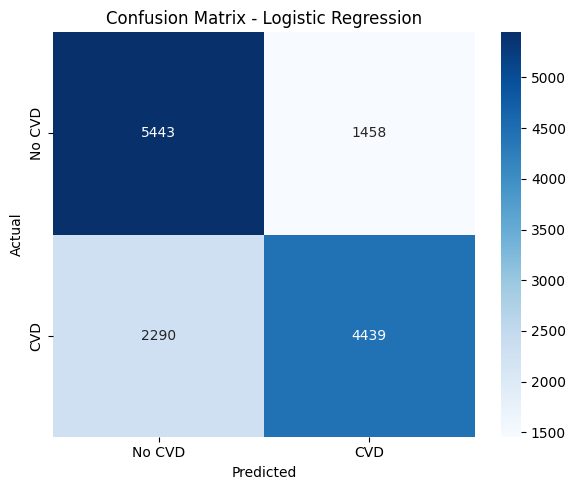

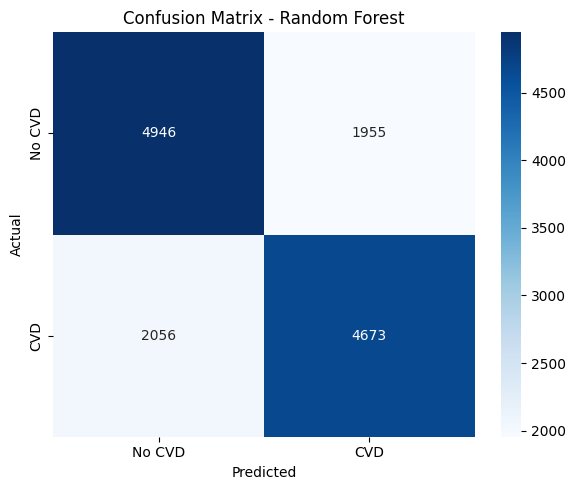

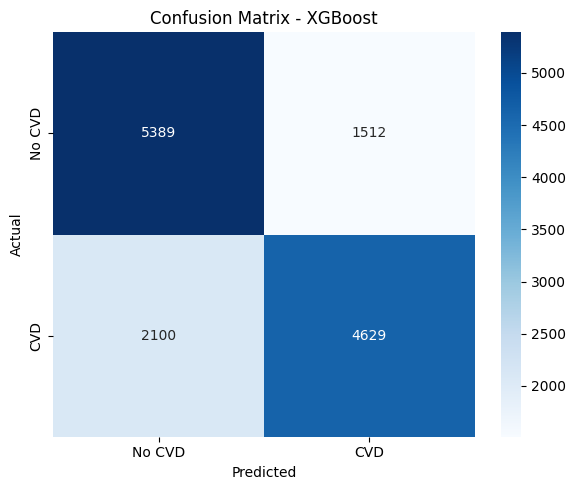

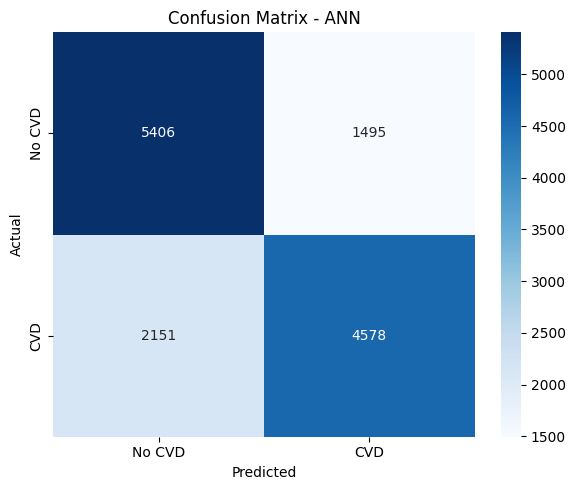

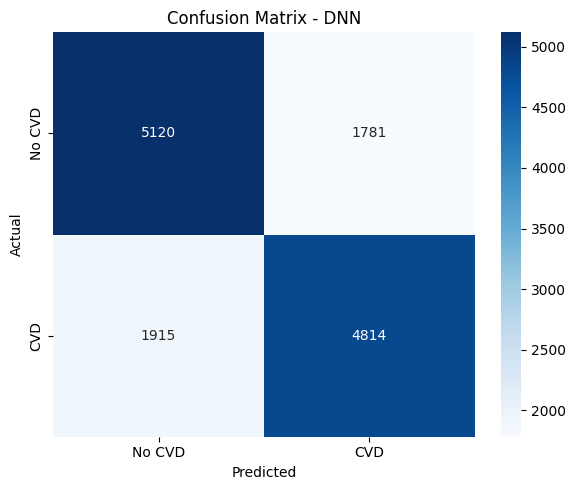

In [45]:
# ============================================================
# PART 7.1: CONFUSION MATRICES
# ============================================================

for model_name in models:

    y_pred = predictions[model_name]

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No CVD", "CVD"],
        yticklabels=["No CVD", "CVD"]
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

In [46]:
# ============================================================
# PART 7.2: CLASSIFICATION REPORTS
# ============================================================

for model_name in models:

    print("=" * 70)
    print(model_name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            predictions[model_name],
            target_names=["No CVD", "CVD"]
        )
    )

Logistic Regression
              precision    recall  f1-score   support

      No CVD       0.70      0.79      0.74      6901
         CVD       0.75      0.66      0.70      6729

    accuracy                           0.73     13630
   macro avg       0.73      0.72      0.72     13630
weighted avg       0.73      0.73      0.72     13630

Random Forest
              precision    recall  f1-score   support

      No CVD       0.71      0.72      0.71      6901
         CVD       0.71      0.69      0.70      6729

    accuracy                           0.71     13630
   macro avg       0.71      0.71      0.71     13630
weighted avg       0.71      0.71      0.71     13630

XGBoost
              precision    recall  f1-score   support

      No CVD       0.72      0.78      0.75      6901
         CVD       0.75      0.69      0.72      6729

    accuracy                           0.73     13630
   macro avg       0.74      0.73      0.73     13630
weighted avg       0.74      0.7

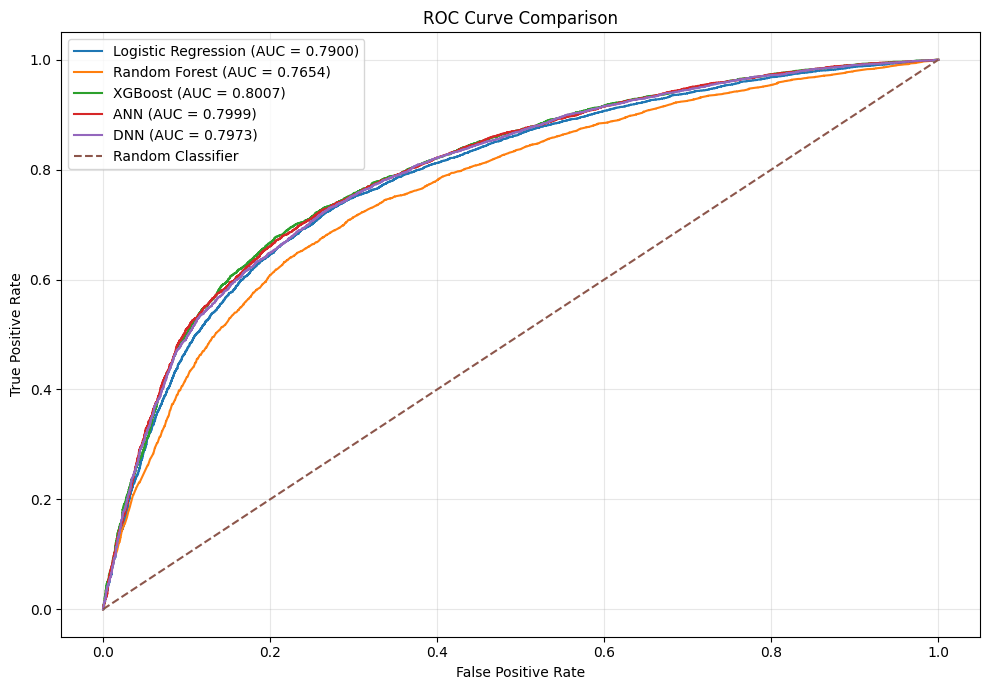

In [47]:
# ============================================================
# PART 7.3: ROC CURVES
# ============================================================

plt.figure(figsize=(10, 7))

for model_name in models:

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities[model_name]
    )

    auc_score = roc_auc_score(
        y_test,
        probabilities[model_name]
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {auc_score:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [48]:
# ============================================================
# PART 7.4: XGBOOST FEATURE IMPORTANCE
# ============================================================

xgb_importance = pd.DataFrame({
    "Feature": X_eng_train.columns,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

display(xgb_importance)

,Feature,Importance
4,ap_hi,0.458306
5,ap_lo,0.121798
6,cholesterol,0.115350
0,age_years,0.067510
12,pulse_pressure,0.055718
10,active,0.029858
7,gluc,0.024504
8,smoke,0.022486
9,alco,0.020899
11,bmi_calculated,0.019264


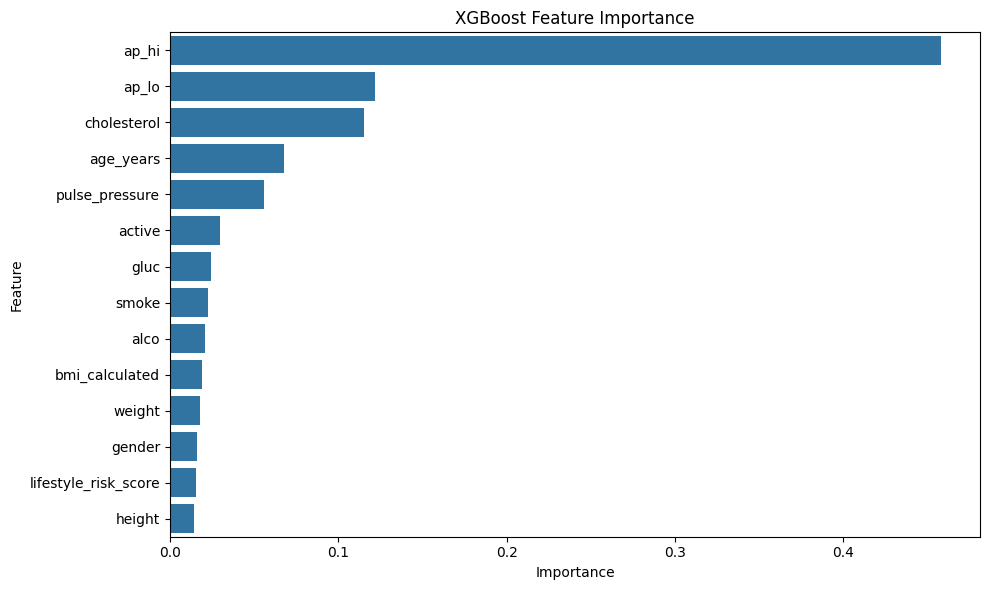

In [49]:
# ============================================================
# XGBOOST FEATURE IMPORTANCE PLOT
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=xgb_importance,
    x="Importance",
    y="Feature"
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [50]:
# ============================================================
# PART 8.1: INSTALL AND IMPORT SHAP
# ============================================================

!pip install -q shap

In [51]:
# ============================================================
# IMPORT SHAP
# ============================================================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [52]:
# ============================================================
# PART 8.2: CREATE SHAP EXPLAINER
# ============================================================

explainer = shap.TreeExplainer(xgb_model)

print("SHAP TreeExplainer created successfully.")

SHAP TreeExplainer created successfully.


In [53]:
# ============================================================
# PART 8.3: CALCULATE SHAP VALUES
# ============================================================

X_shap = X_eng_test.sample(
    n=min(5000, len(X_eng_test)),
    random_state=42
)

shap_values = explainer.shap_values(X_shap)

print("SHAP values calculated successfully.")
print("SHAP dataset shape:", X_shap.shape)
print("SHAP values shape:", np.array(shap_values).shape)

SHAP values calculated successfully.
SHAP dataset shape: (5000, 14)
SHAP values shape: (5000, 14)


In [54]:
# ============================================================
# PART 8.4: GLOBAL SHAP FEATURE IMPORTANCE
# ============================================================

shap_importance = pd.DataFrame({
    "Feature": X_shap.columns,
    "Mean_Absolute_SHAP": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    by="Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

display(shap_importance)

,Feature,Mean_Absolute_SHAP
0,ap_hi,0.692238
1,age_years,0.280606
2,cholesterol,0.226689
3,ap_lo,0.167505
4,pulse_pressure,0.080062
5,bmi_calculated,0.077578
6,active,0.066575
7,weight,0.064986
8,gluc,0.043486
9,height,0.033477


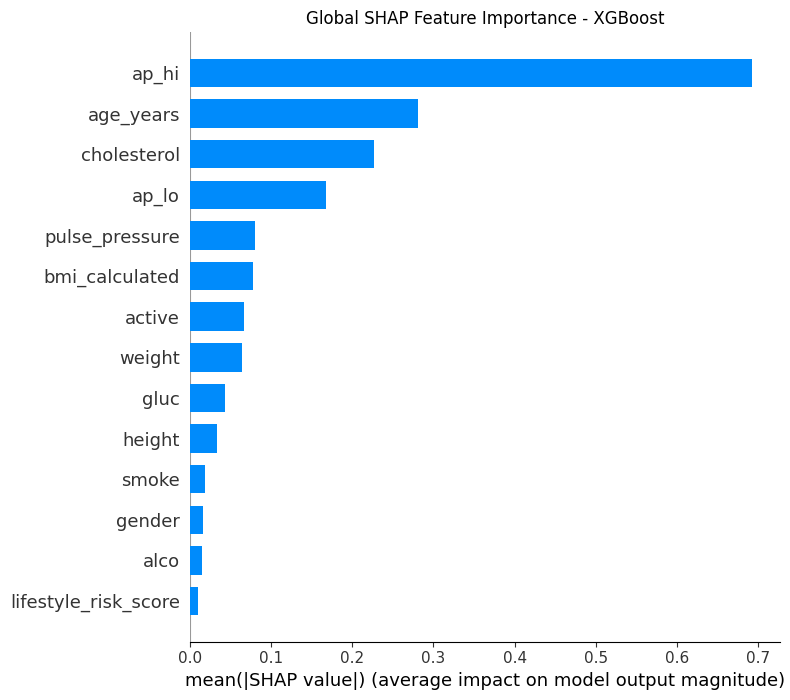

In [ ]:
# ============================================================
# PART 8.5: SHAP GLOBAL BAR PLOT
# ============================================================

plt.figure()

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    show=False
)

plt.title("Global SHAP Feature Importance - XGBoost")
plt.tight_layout()
plt.show()

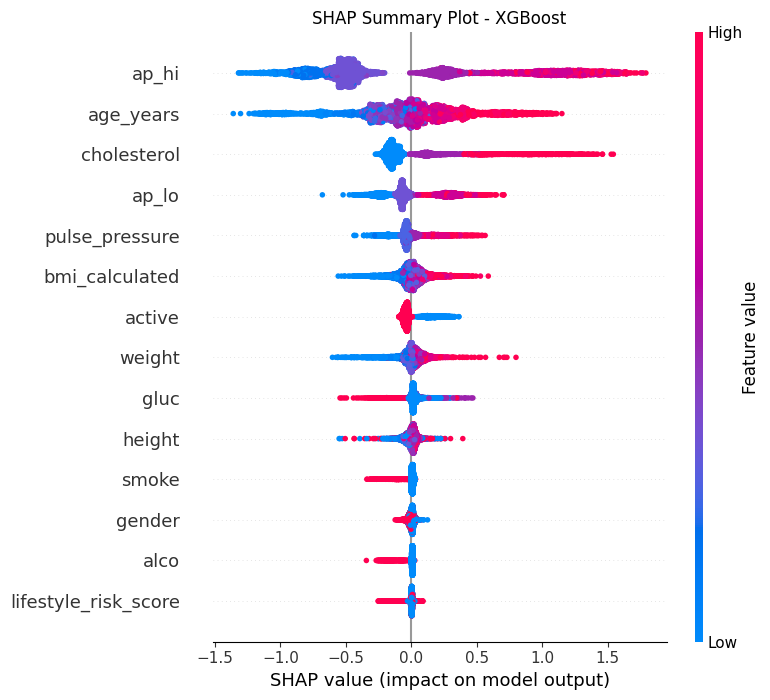

In [55]:
# ============================================================
# PART 8.6: SHAP SUMMARY PLOT
# ============================================================

plt.figure()

shap.summary_plot(
    shap_values,
    X_shap,
    show=False
)

plt.title("SHAP Summary Plot - XGBoost")
plt.tight_layout()
plt.show()

In [56]:
# ============================================================
# PART 8.11: SELECT INDIVIDUAL PATIENT
# ============================================================

patient_index = 0

patient = X_eng_test.iloc[[patient_index]]

patient_prediction = xgb_model.predict(patient)[0]

patient_probability = xgb_model.predict_proba(patient)[0, 1]

print("Patient prediction:", patient_prediction)
print("Predicted CVD probability:", round(patient_probability * 100, 2), "%")

Patient prediction: 0
Predicted CVD probability: 34.93 %


In [57]:
# ============================================================
# PART 8.12: INDIVIDUAL PATIENT SHAP VALUES
# ============================================================

patient_shap_values = explainer.shap_values(patient)

patient_explanation = pd.DataFrame({
    "Feature": patient.columns,
    "Feature_Value": patient.iloc[0].values,
    "SHAP_Value": patient_shap_values[0]
})

patient_explanation["Absolute_SHAP"] = (
    patient_explanation["SHAP_Value"].abs()
)

patient_explanation = patient_explanation.sort_values(
    by="Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

display(patient_explanation)

,Feature,Feature_Value,SHAP_Value,Absolute_SHAP
0,ap_hi,110.000000,-0.689074,0.689074
1,age_years,59.000000,0.430175,0.430175
2,ap_lo,70.000000,-0.209529,0.209529
3,cholesterol,1.000000,-0.154795,0.154795
4,active,1.000000,-0.040233,0.040233
5,gender,1.000000,0.022479,0.022479
6,pulse_pressure,40.000000,-0.018980,0.018980
7,height,169.000000,0.016829,0.016829
8,gluc,1.000000,0.013964,0.013964
9,weight,70.000000,0.011345,0.011345


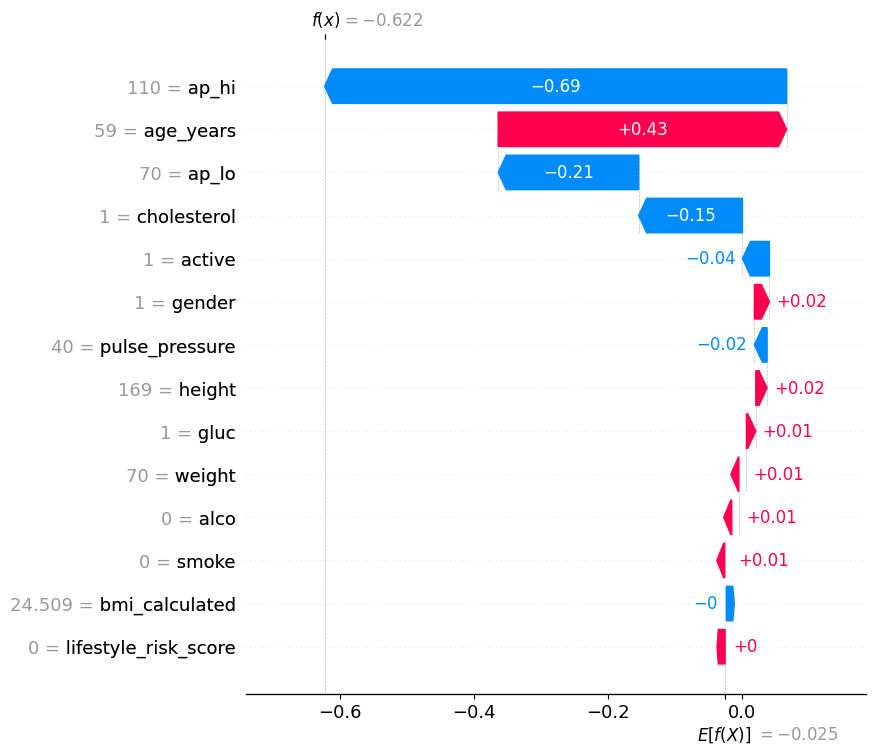

In [58]:
# ============================================================
# PART 8.13: SHAP WATERFALL PLOT
# ============================================================

patient_shap_explanation = shap.Explanation(
    values=patient_shap_values[0],
    base_values=explainer.expected_value,
    data=patient.iloc[0].values,
    feature_names=patient.columns.tolist()
)

shap.plots.waterfall(
    patient_shap_explanation,
    max_display=14
)

In [59]:
# ============================================================
# PART 8.14: TOP POSITIVE AND NEGATIVE CONTRIBUTORS
# ============================================================

positive_contributors = patient_explanation[
    patient_explanation["SHAP_Value"] > 0
].head(5)

negative_contributors = patient_explanation[
    patient_explanation["SHAP_Value"] < 0
].head(5)

print("TOP FACTORS INCREASING PREDICTED CVD RISK")
print("=" * 50)

display(
    positive_contributors[
        ["Feature", "Feature_Value", "SHAP_Value"]
    ]
)

print("\nTOP FACTORS DECREASING PREDICTED CVD RISK")
print("=" * 50)

display(
    negative_contributors[
        ["Feature", "Feature_Value", "SHAP_Value"]
    ]
)

TOP FACTORS INCREASING PREDICTED CVD RISK


,Feature,Feature_Value,SHAP_Value
1,age_years,59.0,0.430175
5,gender,1.0,0.022479
7,height,169.0,0.016829
8,gluc,1.0,0.013964
9,weight,70.0,0.011345



TOP FACTORS DECREASING PREDICTED CVD RISK


,Feature,Feature_Value,SHAP_Value
0,ap_hi,110.0,-0.689074
2,ap_lo,70.0,-0.209529
3,cholesterol,1.0,-0.154795
4,active,1.0,-0.040233
6,pulse_pressure,40.0,-0.018980


In [60]:
# ============================================================
# PART 8.15: SAVE SHAP FEATURE IMPORTANCE
# ============================================================

shap_importance.to_csv(
    "/content/shap_feature_importance.csv",
    index=False
)

print("SHAP feature importance saved successfully.")

SHAP feature importance saved successfully.


In [61]:
# ============================================================
# PART 9.1: XGBOOST PREDICTED PROBABILITIES
# ============================================================

xgb_probabilities = xgb_model.predict_proba(
    X_eng_test
)[:, 1]

print("Predicted probabilities generated successfully.")

print("\nMinimum probability:",
      round(xgb_probabilities.min(), 4))

print("Maximum probability:",
      round(xgb_probabilities.max(), 4))

print("Mean probability:",
      round(xgb_probabilities.mean(), 4))

Predicted probabilities generated successfully.

Minimum probability: 0.0231
Maximum probability: 0.9543
Mean probability: 0.4924


In [62]:
# ============================================================
# PART 9.2: RISK STRATIFICATION FUNCTION
# ============================================================

def classify_risk(probability):

    if probability < 0.25:
        return "Low"

    elif probability < 0.50:
        return "Moderate"

    elif probability < 0.75:
        return "High"

    else:
        return "Very High"

In [63]:
# ============================================================
# PART 9.3: APPLY RISK LEVELS
# ============================================================

risk_levels = [
    classify_risk(probability)
    for probability in xgb_probabilities
]

risk_results = pd.DataFrame({
    "Actual_CVD": y_test.values,
    "Predicted_Probability": xgb_probabilities,
    "Risk_Level": risk_levels
})

display(risk_results.head(10))

,Actual_CVD,Predicted_Probability,Risk_Level
0,0,0.349258,Moderate
1,1,0.912111,Very High
2,0,0.309084,Moderate
3,0,0.093125,Low
4,0,0.472216,Moderate
5,0,0.720114,High
6,0,0.352232,Moderate
7,0,0.117143,Low
8,1,0.869004,Very High
9,1,0.769352,Very High


In [64]:
# ============================================================
# PART 9.4: RISK LEVEL DISTRIBUTION
# ============================================================

risk_distribution = (
    risk_results["Risk_Level"]
    .value_counts()
    .reindex(
        ["Low", "Moderate", "High", "Very High"],
        fill_value=0
    )
)

print("Risk Level Distribution:")
print(risk_distribution)

print("\nRisk Level Percentages:")
print(
    (risk_distribution / len(risk_results) * 100).round(2)
)

Risk Level Distribution:
Risk_Level
Low          3089
Moderate     4400
High         2316
Very High    3825
Name: count, dtype: int64

Risk Level Percentages:
Risk_Level
Low          22.66
Moderate     32.28
High         16.99
Very High    28.06
Name: count, dtype: float64


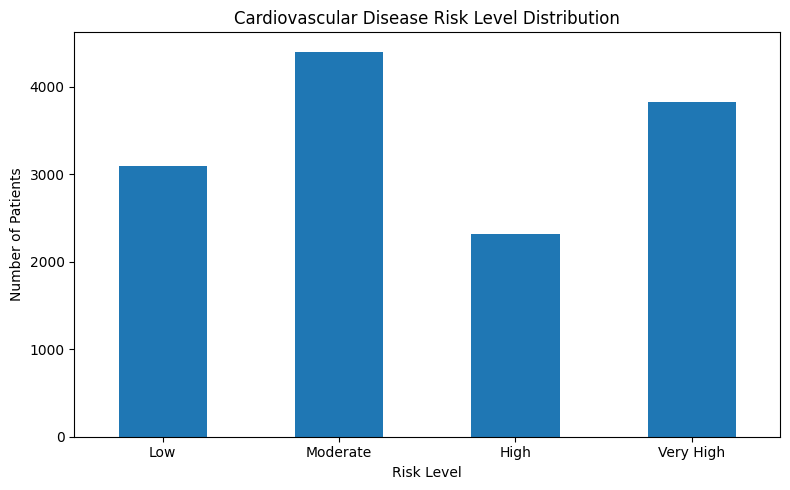

In [65]:
# ============================================================
# PART 9.5: RISK LEVEL DISTRIBUTION PLOT
# ============================================================

plt.figure(figsize=(8, 5))

risk_distribution.plot(
    kind="bar"
)

plt.title("Cardiovascular Disease Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [66]:
# ============================================================
# PART 9.6: RISK LEVEL VS ACTUAL CVD
# ============================================================

risk_cvd_table = pd.crosstab(
    risk_results["Risk_Level"],
    risk_results["Actual_CVD"]
)

risk_cvd_table = risk_cvd_table.reindex(
    ["Low", "Moderate", "High", "Very High"]
)

risk_cvd_table.columns = [
    "No CVD",
    "CVD"
]

display(risk_cvd_table)

,No CVD,CVD
Risk_Level,,
Low,2585,504
Moderate,2804,1596
High,895,1421
Very High,617,3208


In [67]:
# ============================================================
# PART 9.6B: ACTUAL CVD RATE WITHIN EACH RISK LEVEL
# ============================================================

risk_cvd_rate = (
    risk_results
    .groupby("Risk_Level")["Actual_CVD"]
    .mean()
    .reindex(["Low", "Moderate", "High", "Very High"])
    * 100
)

risk_cvd_rate = risk_cvd_rate.round(2)

print("Actual CVD percentage within each predicted risk level:")
display(risk_cvd_rate)

Actual CVD percentage within each predicted risk level:


,Actual_CVD
Risk_Level,
Low,16.32
Moderate,36.27
High,61.36
Very High,83.87


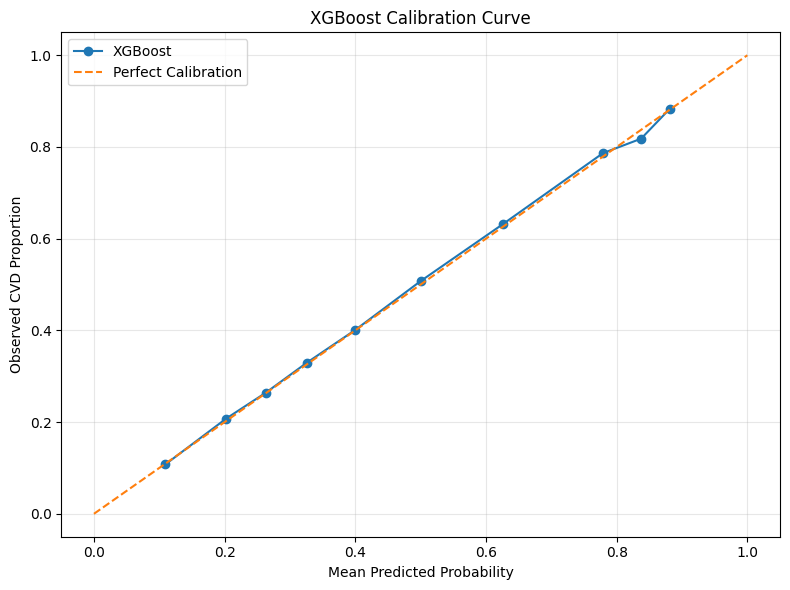

In [68]:
# ============================================================
# PART 9.7: CALIBRATION CURVE
# ============================================================

from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    y_test,
    xgb_probabilities,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(8, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="XGBoost"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed CVD Proportion")
plt.title("XGBoost Calibration Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [69]:
# ============================================================
# PART 9.8: BRIER SCORE
# ============================================================

from sklearn.metrics import brier_score_loss

brier_score = brier_score_loss(
    y_test,
    xgb_probabilities
)

print("XGBoost Brier Score:",
      round(brier_score, 4))

XGBoost Brier Score: 0.1811


In [70]:
# ============================================================
# PART 9.9: CALIBRATION TABLE
# ============================================================

calibration_table = pd.DataFrame({
    "Mean_Predicted_Probability": prob_pred,
    "Observed_CVD_Proportion": prob_true
})

calibration_table["Difference"] = (
    calibration_table["Mean_Predicted_Probability"]
    - calibration_table["Observed_CVD_Proportion"]
)

display(
    calibration_table.round(4)
)

,Mean_Predicted_Probability,Observed_CVD_Proportion,Difference
0,0.1094,0.1078,0.0016
1,0.2025,0.2078,-0.0053
2,0.2630,0.2641,-0.0011
3,0.3258,0.3294,-0.0036
4,0.4003,0.4013,-0.0010
5,0.5002,0.5077,-0.0075
6,0.6259,0.6317,-0.0058
7,0.7790,0.7865,-0.0075
8,0.8374,0.8180,0.0193
9,0.8809,0.8826,-0.0017


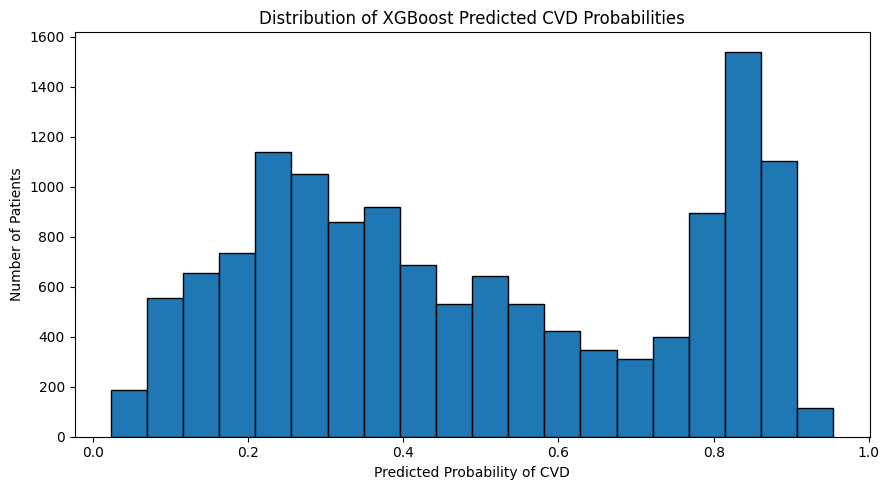

In [71]:
# ============================================================
# PART 9.10: PROBABILITY DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 5))

plt.hist(
    xgb_probabilities,
    bins=20,
    edgecolor="black"
)

plt.xlabel("Predicted Probability of CVD")
plt.ylabel("Number of Patients")
plt.title("Distribution of XGBoost Predicted CVD Probabilities")
plt.tight_layout()
plt.show()

In [72]:
# ============================================================
# PART 10.1: CREATE FAIRNESS EVALUATION DATASET
# ============================================================

fairness_df = X_eng_test.copy()

fairness_df["Actual_CVD"] = y_test.values
fairness_df["Predicted_CVD"] = xgb_predictions
fairness_df["Predicted_Probability"] = xgb_probabilities

print("Fairness evaluation dataset created.")
print("Shape:", fairness_df.shape)

display(fairness_df.head())

Fairness evaluation dataset created.
Shape: (13630, 17)


,age_years,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,bmi_calculated,pulse_pressure,lifestyle_risk_score,Actual_CVD,Predicted_CVD,Predicted_Probability
47103,59,1,169,70.0,110,70,1,1,0,0,1,24.508946,40,0,0,0,0.349258
16110,53,1,150,68.0,180,100,1,1,0,0,1,30.222222,80,0,1,1,0.912111
42528,48,1,163,64.0,110,70,2,1,0,0,1,24.088223,40,0,0,0,0.309084
50361,49,1,159,49.0,110,80,1,1,0,0,1,19.382145,30,0,0,0,0.093125
5305,57,1,166,65.0,120,70,2,1,0,0,0,23.588329,50,1,0,0,0.472216


In [73]:
# ============================================================
# PART 10.2: CREATE GENDER GROUPS
# ============================================================

fairness_df["Gender_Group"] = fairness_df["gender"].map({
    1: "Female",
    2: "Male"
})

print("Gender distribution:")
print(fairness_df["Gender_Group"].value_counts())

Gender distribution:
Gender_Group
Female    8903
Male      4727
Name: count, dtype: int64


In [74]:
# ============================================================
# PART 10.3: CREATE AGE GROUPS
# ============================================================

def create_age_group(age):

    if age <= 30:
        return "18-30"

    elif age <= 45:
        return "31-45"

    elif age <= 60:
        return "46-60"

    else:
        return "60+"

fairness_df["Age_Group"] = (
    fairness_df["age_years"]
    .apply(create_age_group)
)

print("Age group distribution:")
print(fairness_df["Age_Group"].value_counts())

Age group distribution:
Age_Group
46-60    9307
31-45    2386
60+      1936
18-30       1
Name: count, dtype: int64


In [75]:
# ============================================================
# PART 10.4: FAIRNESS METRICS FUNCTION
# ============================================================

def calculate_fairness_metrics(data, group_column):

    results = []

    for group in data[group_column].dropna().unique():

        group_data = data[
            data[group_column] == group
        ]

        y_true_group = group_data["Actual_CVD"]
        y_pred_group = group_data["Predicted_CVD"]

        tn, fp, fn, tp = confusion_matrix(
            y_true_group,
            y_pred_group,
            labels=[0, 1]
        ).ravel()

        total = tn + fp + fn + tp

        accuracy = (
            (tp + tn) / total
            if total > 0 else 0
        )

        precision = (
            tp / (tp + fp)
            if (tp + fp) > 0 else 0
        )

        recall = (
            tp / (tp + fn)
            if (tp + fn) > 0 else 0
        )

        false_positive_rate = (
            fp / (fp + tn)
            if (fp + tn) > 0 else 0
        )

        false_negative_rate = (
            fn / (fn + tp)
            if (fn + tp) > 0 else 0
        )

        results.append({
            "Group": group,
            "Sample_Size": total,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "False_Positive_Rate": false_positive_rate,
            "False_Negative_Rate": false_negative_rate
        })

    return pd.DataFrame(results)

In [76]:
# ============================================================
# PART 10.5: GENDER FAIRNESS
# ============================================================

gender_fairness = calculate_fairness_metrics(
    fairness_df,
    "Gender_Group"
)

display(
    gender_fairness.round(4)
)

,Group,Sample_Size,Accuracy,Precision,Recall,False_Positive_Rate,False_Negative_Rate
0,Female,8903,0.7373,0.7545,0.6929,0.2195,0.3071
1,Male,4727,0.7307,0.7524,0.6786,0.2184,0.3214


In [77]:
# ============================================================
# PART 10.6: AGE-GROUP FAIRNESS
# ============================================================

age_fairness = calculate_fairness_metrics(
    fairness_df,
    "Age_Group"
)

age_order = [
    "18-30",
    "31-45",
    "46-60",
    "60+"
]

age_fairness["Group"] = pd.Categorical(
    age_fairness["Group"],
    categories=age_order,
    ordered=True
)

age_fairness = age_fairness.sort_values(
    "Group"
).reset_index(drop=True)

display(
    age_fairness.round(4)
)

,Group,Sample_Size,Accuracy,Precision,Recall,False_Positive_Rate,False_Negative_Rate
0,18-30,1,1.0000,0.0000,0.0000,0.0000,0.0000
1,31-45,2386,0.8210,0.7829,0.6042,0.0780,0.3958
2,46-60,9307,0.7197,0.7568,0.6417,0.2034,0.3583
3,60+,1936,0.7025,0.7361,0.8933,0.7359,0.1067


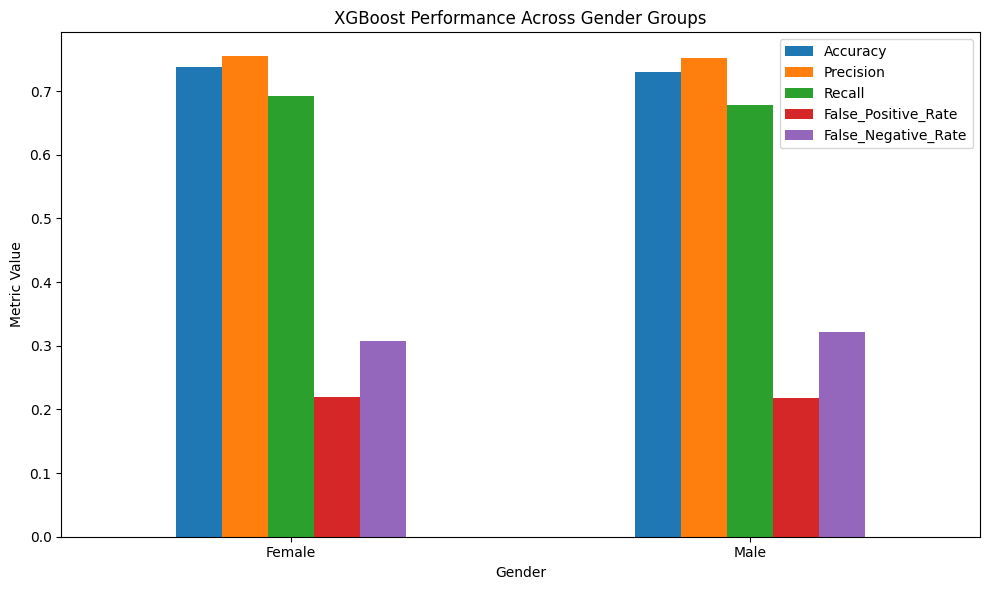

In [78]:
# ============================================================
# PART 10.7: GENDER PERFORMANCE COMPARISON
# ============================================================

gender_plot_data = gender_fairness.set_index(
    "Group"
)[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "False_Positive_Rate",
        "False_Negative_Rate"
    ]
]

gender_plot_data.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("XGBoost Performance Across Gender Groups")
plt.xlabel("Gender")
plt.ylabel("Metric Value")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

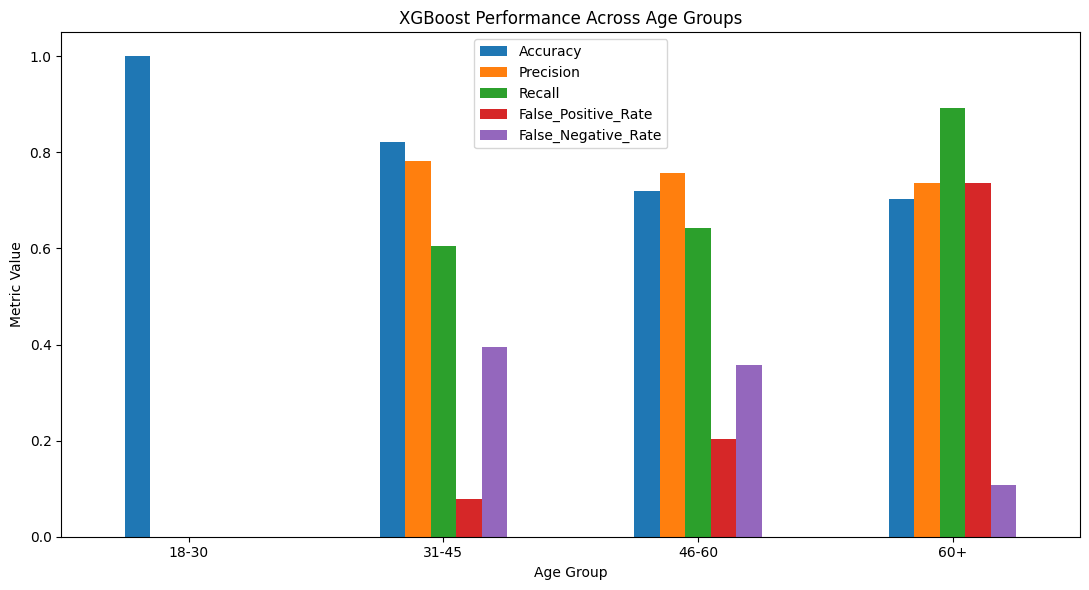

In [79]:
# ============================================================
# PART 10.8: AGE GROUP PERFORMANCE COMPARISON
# ============================================================

age_plot_data = age_fairness.set_index(
    "Group"
)[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "False_Positive_Rate",
        "False_Negative_Rate"
    ]
]

age_plot_data.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("XGBoost Performance Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Metric Value")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

In [80]:
# ============================================================
# PART 10.9: GENDER PERFORMANCE DIFFERENCES
# ============================================================

gender_difference = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "False Positive Rate",
        "False Negative Rate"
    ],
    "Difference": [
        gender_fairness["Accuracy"].max()
        - gender_fairness["Accuracy"].min(),

        gender_fairness["Precision"].max()
        - gender_fairness["Precision"].min(),

        gender_fairness["Recall"].max()
        - gender_fairness["Recall"].min(),

        gender_fairness["False_Positive_Rate"].max()
        - gender_fairness["False_Positive_Rate"].min(),

        gender_fairness["False_Negative_Rate"].max()
        - gender_fairness["False_Negative_Rate"].min()
    ]
})

display(
    gender_difference.round(4)
)

,Metric,Difference
0,Accuracy,0.0066
1,Precision,0.0022
2,Recall,0.0142
3,False Positive Rate,0.0011
4,False Negative Rate,0.0142


In [81]:
# ============================================================
# PART 10.10: AGE PERFORMANCE DIFFERENCES
# ============================================================

age_difference = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "False Positive Rate",
        "False Negative Rate"
    ],
    "Difference": [
        age_fairness["Accuracy"].max()
        - age_fairness["Accuracy"].min(),

        age_fairness["Precision"].max()
        - age_fairness["Precision"].min(),

        age_fairness["Recall"].max()
        - age_fairness["Recall"].min(),

        age_fairness["False_Positive_Rate"].max()
        - age_fairness["False_Positive_Rate"].min(),

        age_fairness["False_Negative_Rate"].max()
        - age_fairness["False_Negative_Rate"].min()
    ]
})

display(
    age_difference.round(4)
)

,Metric,Difference
0,Accuracy,0.2975
1,Precision,0.7829
2,Recall,0.8933
3,False Positive Rate,0.7359
4,False Negative Rate,0.3958


In [82]:
# ============================================================
# PART 10.11A: PREDICTED PROBABILITY BY GENDER
# ============================================================

gender_probability = (
    fairness_df
    .groupby("Gender_Group")["Predicted_Probability"]
    .agg(["mean", "median", "std"])
    .reset_index()
)

gender_probability.columns = [
    "Gender",
    "Mean_Probability",
    "Median_Probability",
    "Std_Probability"
]

display(
    gender_probability.round(4)
)

,Gender,Mean_Probability,Median_Probability,Std_Probability
0,Female,0.4898,0.4401,0.2646
1,Male,0.4973,0.4510,0.2628


In [83]:
# ============================================================
# PART 10.11B: PREDICTED PROBABILITY BY AGE GROUP
# ============================================================

age_probability = (
    fairness_df
    .groupby("Age_Group")["Predicted_Probability"]
    .agg(["mean", "median", "std"])
    .reindex(age_order)
    .reset_index()
)

age_probability.columns = [
    "Age_Group",
    "Mean_Probability",
    "Median_Probability",
    "Std_Probability"
]

display(
    age_probability.round(4)
)

,Age_Group,Mean_Probability,Median_Probability,Std_Probability
0,18-30,0.0807,0.0807,NaN
1,31-45,0.3242,0.1962,0.2802
2,46-60,0.4949,0.4242,0.2471
3,60+,0.6882,0.7066,0.1648


In [84]:
# ============================================================
# PART 10.13: FAIRNESS SUMMARY
# ============================================================

print("=" * 70)
print("FAIRNESS AND BIAS EVALUATION SUMMARY")
print("=" * 70)

print("\nGender Fairness:")
display(gender_fairness.round(4))

print("\nGender Performance Differences:")
display(gender_difference.round(4))

print("\nAge Group Fairness:")
display(age_fairness.round(4))

print("\nAge Performance Differences:")
display(age_difference.round(4))

FAIRNESS AND BIAS EVALUATION SUMMARY

Gender Fairness:


,Group,Sample_Size,Accuracy,Precision,Recall,False_Positive_Rate,False_Negative_Rate
0,Female,8903,0.7373,0.7545,0.6929,0.2195,0.3071
1,Male,4727,0.7307,0.7524,0.6786,0.2184,0.3214



Gender Performance Differences:


,Metric,Difference
0,Accuracy,0.0066
1,Precision,0.0022
2,Recall,0.0142
3,False Positive Rate,0.0011
4,False Negative Rate,0.0142



Age Group Fairness:


,Group,Sample_Size,Accuracy,Precision,Recall,False_Positive_Rate,False_Negative_Rate
0,18-30,1,1.0000,0.0000,0.0000,0.0000,0.0000
1,31-45,2386,0.8210,0.7829,0.6042,0.0780,0.3958
2,46-60,9307,0.7197,0.7568,0.6417,0.2034,0.3583
3,60+,1936,0.7025,0.7361,0.8933,0.7359,0.1067



Age Performance Differences:


,Metric,Difference
0,Accuracy,0.2975
1,Precision,0.7829
2,Recall,0.8933
3,False Positive Rate,0.7359
4,False Negative Rate,0.3958


In [85]:
# ============================================================
# PART 11.1: SELECT PATIENT FOR COUNTERFACTUAL ANALYSIS
# ============================================================

patient_index = 0

original_patient = X_eng_test.iloc[[patient_index]].copy()

print("Original patient:")
display(original_patient)

Original patient:


,age_years,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,bmi_calculated,pulse_pressure,lifestyle_risk_score
47103,59,1,169,70.0,110,70,1,1,0,0,1,24.508946,40,0


In [86]:
# ============================================================
# PART 11.2: ORIGINAL PATIENT PREDICTION
# ============================================================

original_probability = xgb_model.predict_proba(
    original_patient
)[0, 1]

original_prediction = xgb_model.predict(
    original_patient
)[0]

print("Original prediction:", original_prediction)
print(
    "Original CVD probability:",
    round(original_probability * 100, 2),
    "%"
)

Original prediction: 0
Original CVD probability: 34.93 %


In [87]:
# ============================================================
# PART 11.3: ORIGINAL RISK LEVEL
# ============================================================

original_risk = classify_risk(
    original_probability
)

print("Original risk level:", original_risk)

Original risk level: Moderate


In [88]:
# ============================================================
# PART 11.4: CREATE COUNTERFACTUAL PATIENT
# ============================================================

counterfactual_patient = original_patient.copy()

print("Counterfactual patient created.")

Counterfactual patient created.


In [89]:
# ============================================================
# PART 11.5: MODIFY BLOOD PRESSURE
# ============================================================

counterfactual_patient["ap_hi"] = 130
counterfactual_patient["ap_lo"] = 80

print("Updated blood pressure:")
print(
    "Systolic BP:",
    counterfactual_patient["ap_hi"].iloc[0]
)

print(
    "Diastolic BP:",
    counterfactual_patient["ap_lo"].iloc[0]
)

Updated blood pressure:
Systolic BP: 130
Diastolic BP: 80


In [90]:
# ============================================================
# PART 11.6: MODIFY WEIGHT AND RECALCULATE BMI
# ============================================================

original_weight = counterfactual_patient["weight"].iloc[0]

new_weight = original_weight * 0.90

counterfactual_patient["weight"] = new_weight

height_m = (
    counterfactual_patient["height"].iloc[0] / 100
)

new_bmi = new_weight / (height_m ** 2)

counterfactual_patient["bmi_calculated"] = new_bmi

print("Original weight:",
      round(original_weight, 2), "kg")

print("Counterfactual weight:",
      round(new_weight, 2), "kg")

print("Counterfactual BMI:",
      round(new_bmi, 2))

Original weight: 70.0 kg
Counterfactual weight: 63.0 kg
Counterfactual BMI: 22.06


In [91]:
# ============================================================
# PART 11.7: MODIFY SMOKING STATUS
# ============================================================

counterfactual_patient["smoke"] = 0

print(
    "Counterfactual smoking status:",
    counterfactual_patient["smoke"].iloc[0]
)

Counterfactual smoking status: 0


In [92]:
# ============================================================
# PART 11.9: RECALCULATE PULSE PRESSURE
# ============================================================

counterfactual_patient["pulse_pressure"] = (
    counterfactual_patient["ap_hi"]
    - counterfactual_patient["ap_lo"]
)

print(
    "Counterfactual pulse pressure:",
    counterfactual_patient["pulse_pressure"].iloc[0]
)

Counterfactual pulse pressure: 50


In [93]:
# ============================================================
# PART 11.10: RECALCULATE LIFESTYLE RISK SCORE
# ============================================================

counterfactual_patient["lifestyle_risk_score"] = (
    counterfactual_patient["smoke"]
    + counterfactual_patient["alco"]
    + (1 - counterfactual_patient["active"])
)

print(
    "Counterfactual lifestyle risk score:",
    counterfactual_patient[
        "lifestyle_risk_score"
    ].iloc[0]
)

Counterfactual lifestyle risk score: 0


In [94]:
# ============================================================
# PART 11.11: COUNTERFACTUAL PREDICTION
# ============================================================

counterfactual_probability = xgb_model.predict_proba(
    counterfactual_patient
)[0, 1]

counterfactual_prediction = xgb_model.predict(
    counterfactual_patient
)[0]

print(
    "Counterfactual prediction:",
    counterfactual_prediction
)

print(
    "Counterfactual CVD probability:",
    round(counterfactual_probability * 100, 2),
    "%"
)

Counterfactual prediction: 1
Counterfactual CVD probability: 53.27 %


In [95]:
# ============================================================
# PART 11.12: COUNTERFACTUAL RISK LEVEL
# ============================================================

counterfactual_risk = classify_risk(
    counterfactual_probability
)

print(
    "Counterfactual risk level:",
    counterfactual_risk
)

Counterfactual risk level: High


In [96]:
# ============================================================
# PART 11.13: CALCULATE RISK CHANGE
# ============================================================

risk_change = (
    original_probability
    - counterfactual_probability
)

percentage_point_change = risk_change * 100

relative_reduction = (
    risk_change / original_probability * 100
    if original_probability > 0
    else 0
)

print(
    "Original risk:",
    round(original_probability * 100, 2),
    "%"
)

print(
    "Counterfactual risk:",
    round(counterfactual_probability * 100, 2),
    "%"
)

print(
    "Risk change:",
    round(percentage_point_change, 2),
    "percentage points"
)

print(
    "Relative risk reduction:",
    round(relative_reduction, 2),
    "%"
)

Original risk: 34.93 %
Counterfactual risk: 53.27 %
Risk change: -18.35 percentage points
Relative risk reduction: -52.53 %


In [97]:
# ============================================================
# PART 11.14: ORIGINAL VS COUNTERFACTUAL COMPARISON
# ============================================================

counterfactual_comparison = pd.DataFrame({
    "Measure": [
        "CVD Probability",
        "Risk Level",
        "Systolic BP",
        "Diastolic BP",
        "Weight",
        "BMI",
        "Smoking",
        "Physical Activity",
        "Pulse Pressure",
        "Lifestyle Risk Score"
    ],

    "Original": [
        round(original_probability * 100, 2),
        original_risk,
        original_patient["ap_hi"].iloc[0],
        original_patient["ap_lo"].iloc[0],
        round(original_patient["weight"].iloc[0], 2),
        round(
            original_patient["bmi_calculated"].iloc[0],
            2
        ),
        original_patient["smoke"].iloc[0],
        original_patient["active"].iloc[0],
        original_patient["pulse_pressure"].iloc[0],
        original_patient["lifestyle_risk_score"].iloc[0]
    ],

    "Counterfactual": [
        round(counterfactual_probability * 100, 2),
        counterfactual_risk,
        counterfactual_patient["ap_hi"].iloc[0],
        counterfactual_patient["ap_lo"].iloc[0],
        round(counterfactual_patient["weight"].iloc[0], 2),
        round(
            counterfactual_patient["bmi_calculated"].iloc[0],
            2
        ),
        counterfactual_patient["smoke"].iloc[0],
        counterfactual_patient["active"].iloc[0],
        counterfactual_patient["pulse_pressure"].iloc[0],
        counterfactual_patient["lifestyle_risk_score"].iloc[0]
    ]
})

display(counterfactual_comparison)

,Measure,Original,Counterfactual
0,CVD Probability,34.93,53.27
1,Risk Level,Moderate,High
2,Systolic BP,110,130
3,Diastolic BP,70,80
4,Weight,70.0,63.0
5,BMI,24.51,22.06
6,Smoking,0,0
7,Physical Activity,1,1
8,Pulse Pressure,40,50
9,Lifestyle Risk Score,0,0


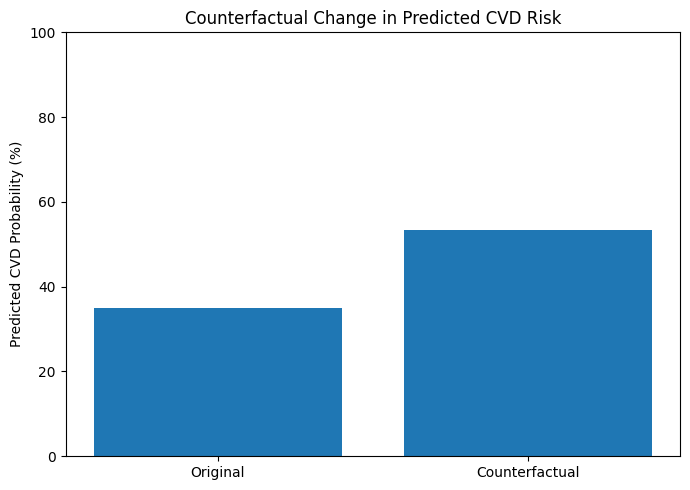

In [98]:
# ============================================================
# PART 11.15: VISUALISE RISK CHANGE
# ============================================================

plt.figure(figsize=(7, 5))

plt.bar(
    ["Original", "Counterfactual"],
    [
        original_probability * 100,
        counterfactual_probability * 100
    ]
)

plt.ylabel("Predicted CVD Probability (%)")
plt.title("Counterfactual Change in Predicted CVD Risk")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

In [ ]:
import joblib

joblib.dump(xgb_model, "/content/xgb_model.pkl")

print("XGBoost model saved successfully.")

XGBoost model saved successfully.


In [ ]:
from google.colab import files

files.download("/content/xgb_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>